<a href="https://colab.research.google.com/github/vikrampal12345/Practice_Revision_Machine_learning/blob/main/3_Both_Encodeing_columnsTransformtion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("/content/adult.csv")
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()        # no null dataset


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df['education'].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


<Axes: xlabel='income', ylabel='age'>

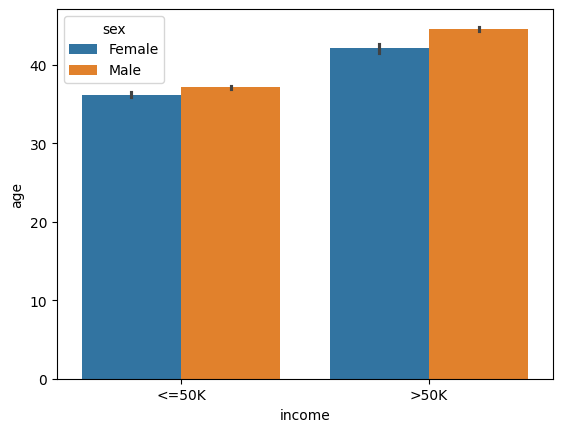

In [ ]:
sns.barplot(data=df, x = 'income', y = 'age', hue = 'sex')

<Axes: xlabel='age', ylabel='education'>

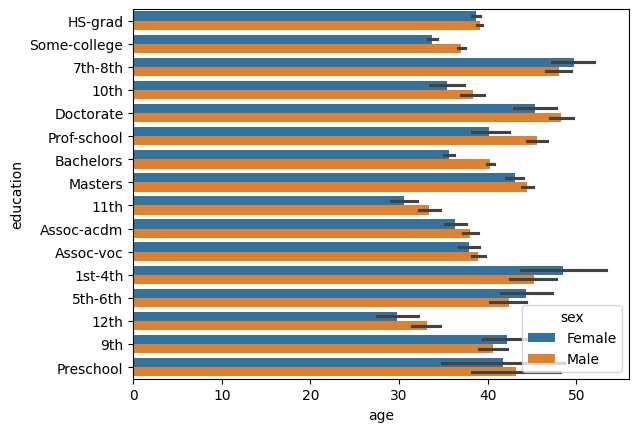

In [ ]:
sns.barplot(data=df, x='age', y='education', hue='sex')

<Axes: xlabel='fnlwgt', ylabel='Count'>

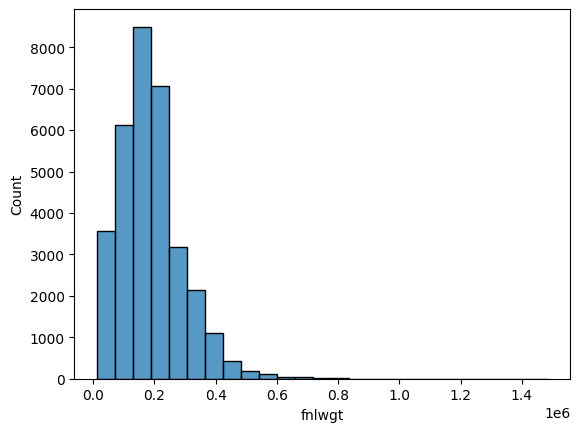

In [ ]:
sns.histplot(df['fnlwgt'], bins=25)

In [ ]:
df['marital.status'].value_counts()

,count
marital.status,
Married-civ-spouse,14976
Never-married,10683
Divorced,4443
Separated,1025
Widowed,993
Married-spouse-absent,418
Married-AF-spouse,23


<Axes: xlabel='age', ylabel='marital.status'>

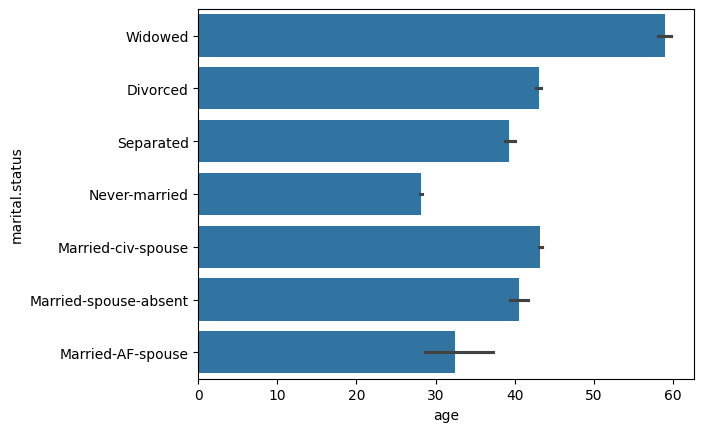

In [ ]:
sns.barplot(data=df, x='age', y='marital.status')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
pd.crosstab(df['marital.status'], df['relationship'])

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
marital.status,,,,,,
Divorced,0,2404,110,328,1601,0
Married-AF-spouse,9,0,1,1,0,12
Married-civ-spouse,13184,17,124,95,0,1556
Married-spouse-absent,0,211,32,45,130,0
Never-married,0,4706,611,4485,881,0
Separated,0,420,55,99,451,0
Widowed,0,547,48,15,383,0


<Axes: xlabel='occupation'>

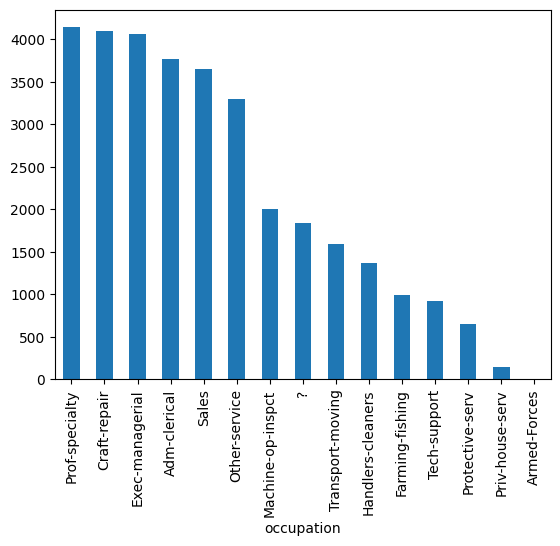

In [ ]:
df['occupation'].value_counts().plot(kind='bar')


<Axes: xlabel='age', ylabel='occupation'>

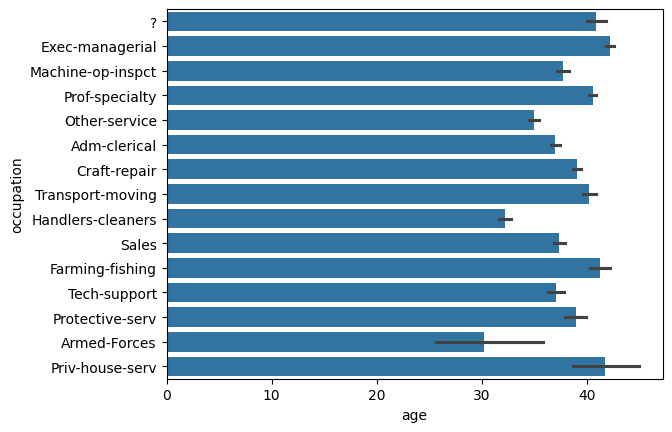

In [ ]:
sns.barplot(data=df, x='age', y = 'occupation')

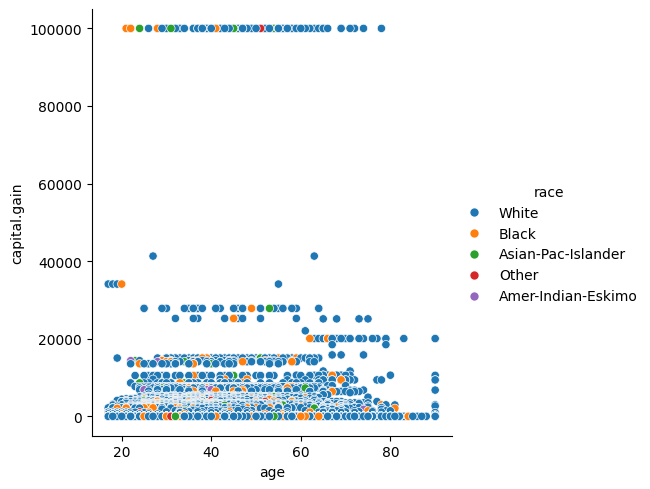

In [ ]:
sns.relplot(data=df, x='age', y='capital.gain', kind='scatter', hue='race')

<Axes: xlabel='race'>

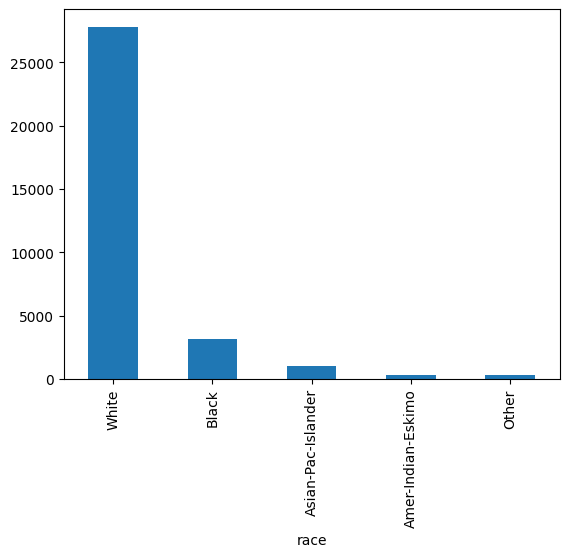

In [ ]:
df['race'].value_counts().plot(kind='bar')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
x=df.drop(columns=['income', 'education.num'])
y=df.iloc[:,-1]
X_train, X_test, y_train, y_test  = train_test_split(x, y , test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((26048, 13), (6513, 13))

In [ ]:
transformer = ColumnTransformer([
    ('trf1', OrdinalEncoder(), ['education']),
    ('trf2', OneHotEncoder(sparse_output=False, drop='first'), ['workclass','marital.status','marital.status', 'relationship', 'race', 'sex', 'native.country', 'occupation'])
], remainder='passthrough')

In [ ]:
X_train_new = transformer.fit_transform(X_train)
X_test_new = transformer.transform(X_test)
X_train_new

array([[1.100e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        2.500e+01],
       [1.100e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        3.500e+01],
       [9.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        4.000e+01],
       ...,
       [1.100e+01, 1.000e+00, 0.000e+00, ..., 0.000e+00, 1.887e+03,
        4.000e+01],
       [1.500e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        5.000e+01],
       [1.100e+01, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        5.000e+01]])

In [ ]:
ohe = LabelEncoder()
y_train_new = ohe.fit_transform(y_train)
y_test_new = ohe.transform(y_test)
y_train_new

array([0, 0, 0, ..., 1, 1, 0])

In [ ]:
le = LogisticRegression(max_iter=1000)
le.fit(X_train_new, y_train_new)

y_pred = le.predict(X_test_new)

accuracy_score(y_test_new, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8297251650545063